# Wave Glider OSSE: Rectangle Array — Spatial-Mean Model Truth

Model truth is WVEL averaged over all model grid points inside the array convex hull,
not just at the centroid.

In [1]:
import json
import numpy as np
import os
import sys
import matplotlib.dates as mdates

os.chdir('/home/edavenport/analysis/tpose24-osse')  # pin working directory

sys.path.insert(0, '/home/edavenport/analysis/tpose24-osse')
from osse_tools import load_model, load_positions, sample_fields, compute_w_planefit, sample_model_w, plot_w_comparison, plot_velocity_map
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration

In [ ]:
RUN_DIR      = '/data/SO3/edavenport/tpose24/oct2012_3month_transp_cons'
ITERS        = list(range(36, 26173, 36))

MAX_DEPTH    = 120
BASE_OUTDIR  = 'spatial_mean/120m'
TITLE        = 'Rectangle array'

CONFIG_FILES = [
    'configs/rectangle/rect_x0.1.json',
    'configs/rectangle/rect_x0.25.json',
    'configs/rectangle/rect_x0.5.json',
    'configs/rectangle/rect_x1.0.json',
]

## Load model (once)

In [3]:
ds = load_model(RUN_DIR, ITERS)
ds = ds.sel(time=slice('2012-10-11', None))  # exclude spin-up

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

...

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

## Run all configurations

In [4]:
results = {}

for cfg_file in CONFIG_FILES:
    with open(cfg_file) as f:
        cfg = json.load(f)
    x         = cfg['x_deg']
    positions = load_positions(cfg_file)

    uv    = sample_fields(ds, positions, vars=('UVEL', 'VVEL'), max_depth=MAX_DEPTH, dz_obs=2)
    w_est = compute_w_planefit(uv)['w_est']
    print(f'x={x}°', end='  ')
    w_model = sample_model_w(ds, positions, max_depth=MAX_DEPTH, dz_obs=2,
                             spatial_mean=True)
    bias = w_est - w_model

    results[x] = dict(
        name=cfg['name'], positions=positions, w_est=w_est, w_model=w_model, bias=bias,
        rms=float(np.sqrt((bias**2).mean())),
        mean_bias=float(bias.mean()),
    )
    print(f"RMS={results[x]['rms']:.3e} m/s  "
          f"bias={results[x]['mean_bias']:+.3e} m/s")

x=0.1°    area mean over 40 model grid points


RMS=1.359e-05 m/s  bias=-3.077e-07 m/s


x=0.25°    area mean over 288 model grid points


RMS=2.034e-05 m/s  bias=-2.520e-06 m/s


x=0.5°    area mean over 1152 model grid points


RMS=2.124e-05 m/s  bias=+3.850e-07 m/s


x=1.0°    area mean over 4608 model grid points


RMS=2.044e-05 m/s  bias=+1.878e-06 m/s


## Per-configuration figures

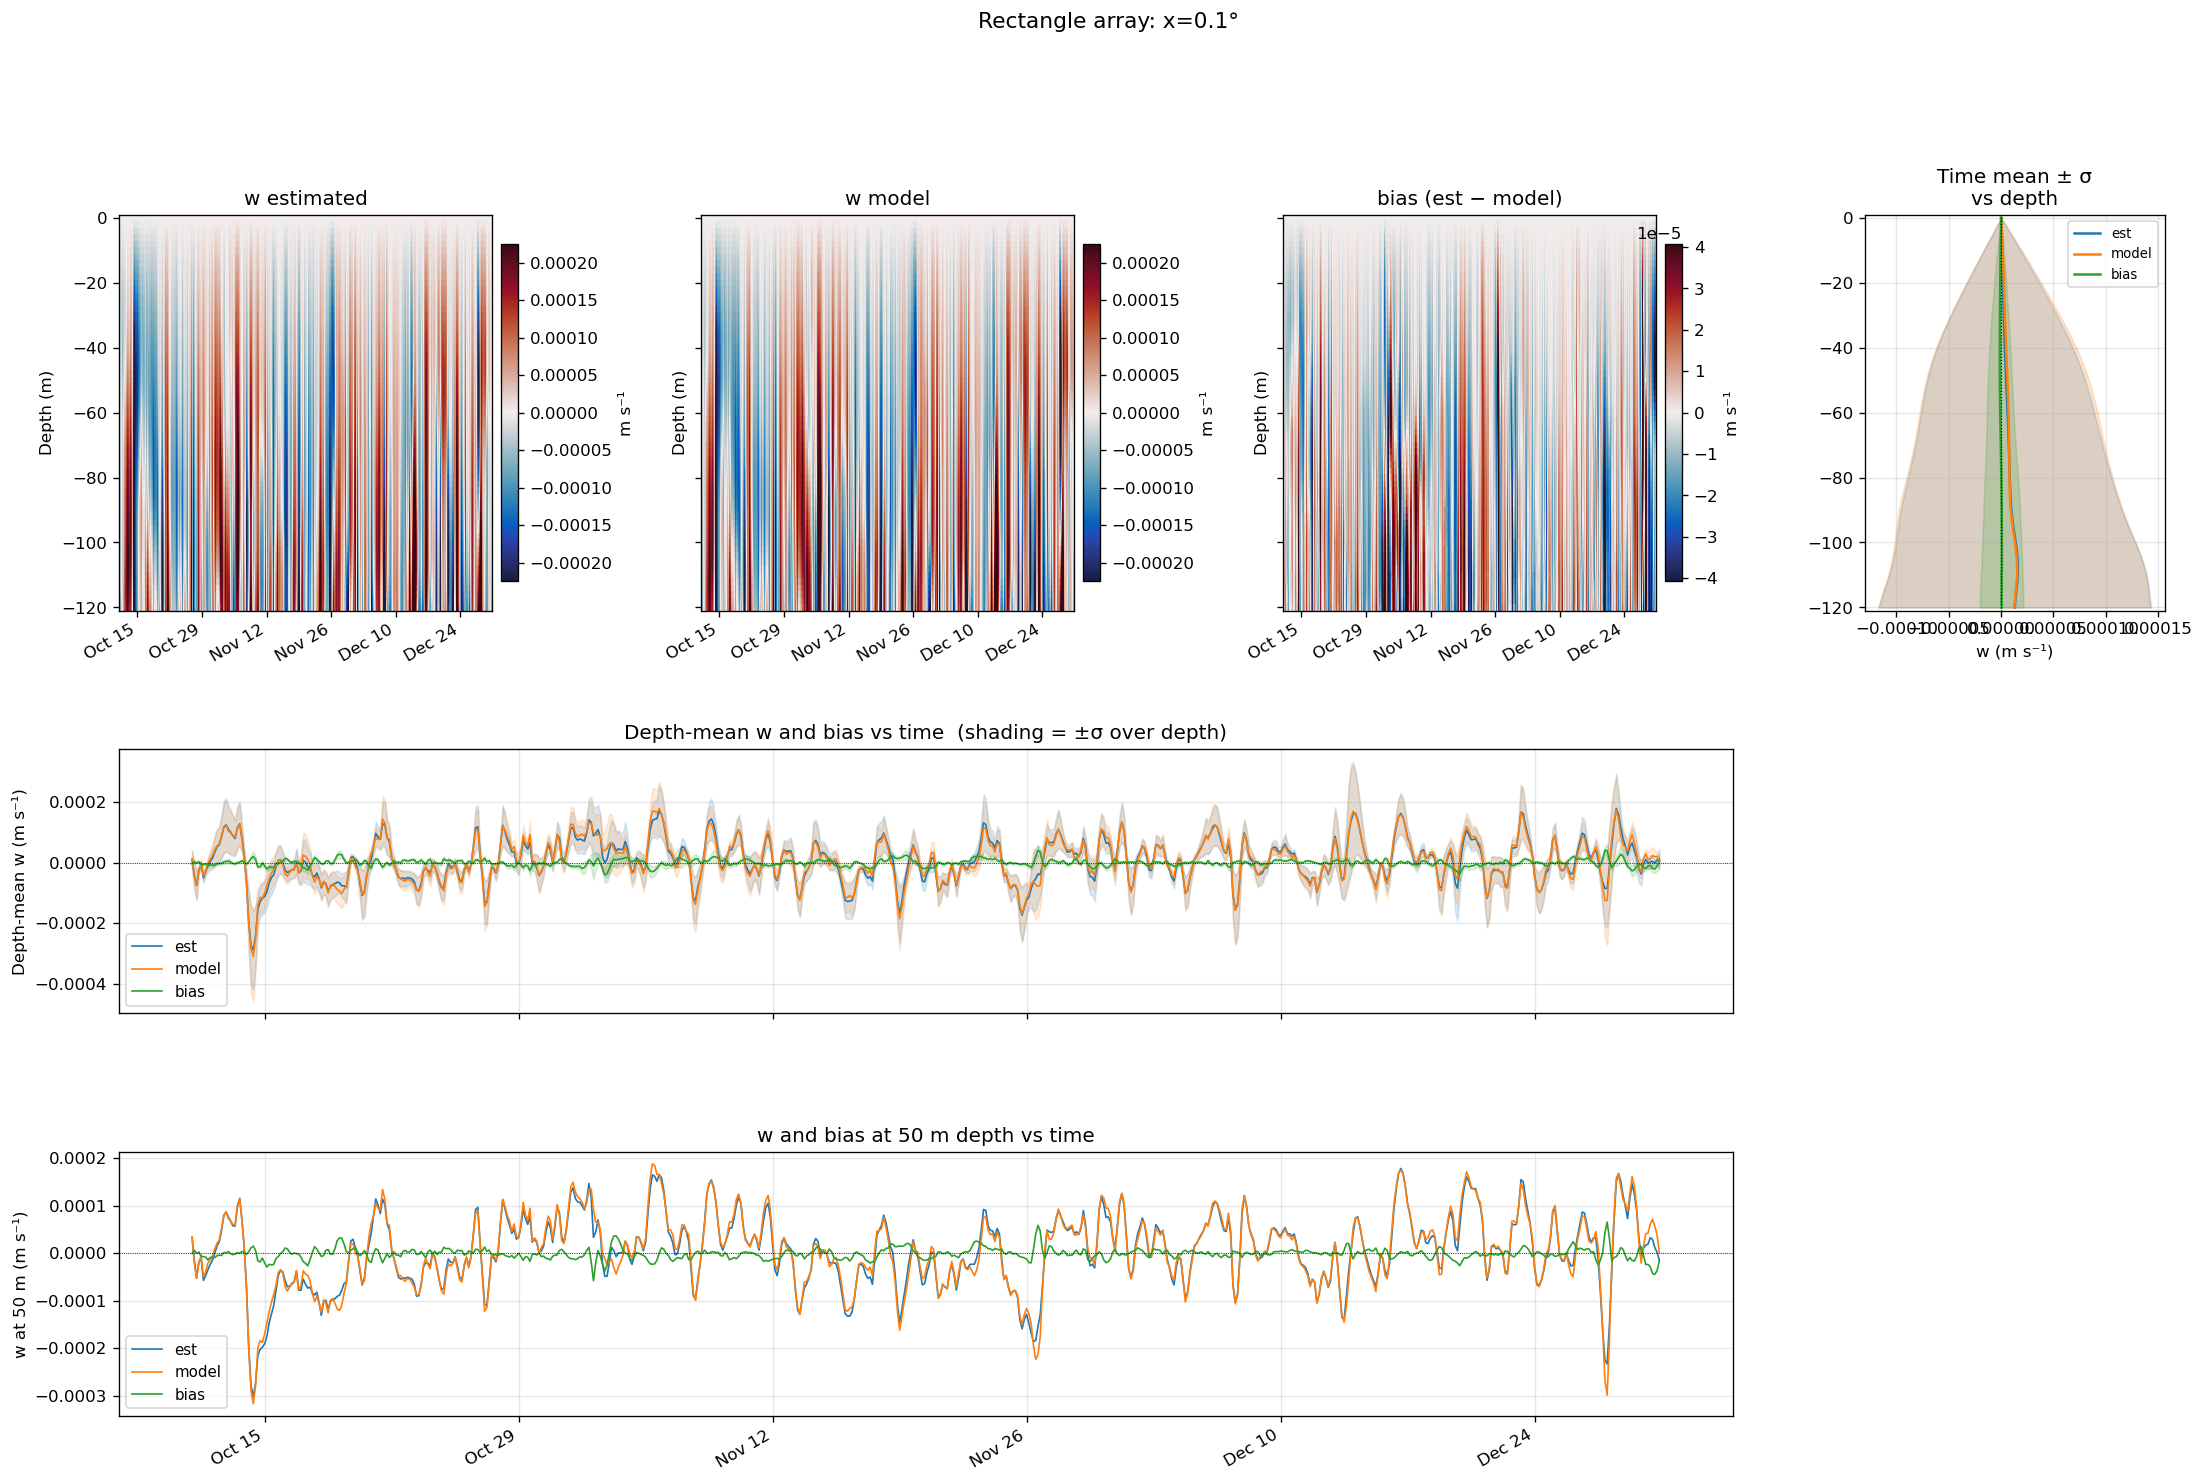

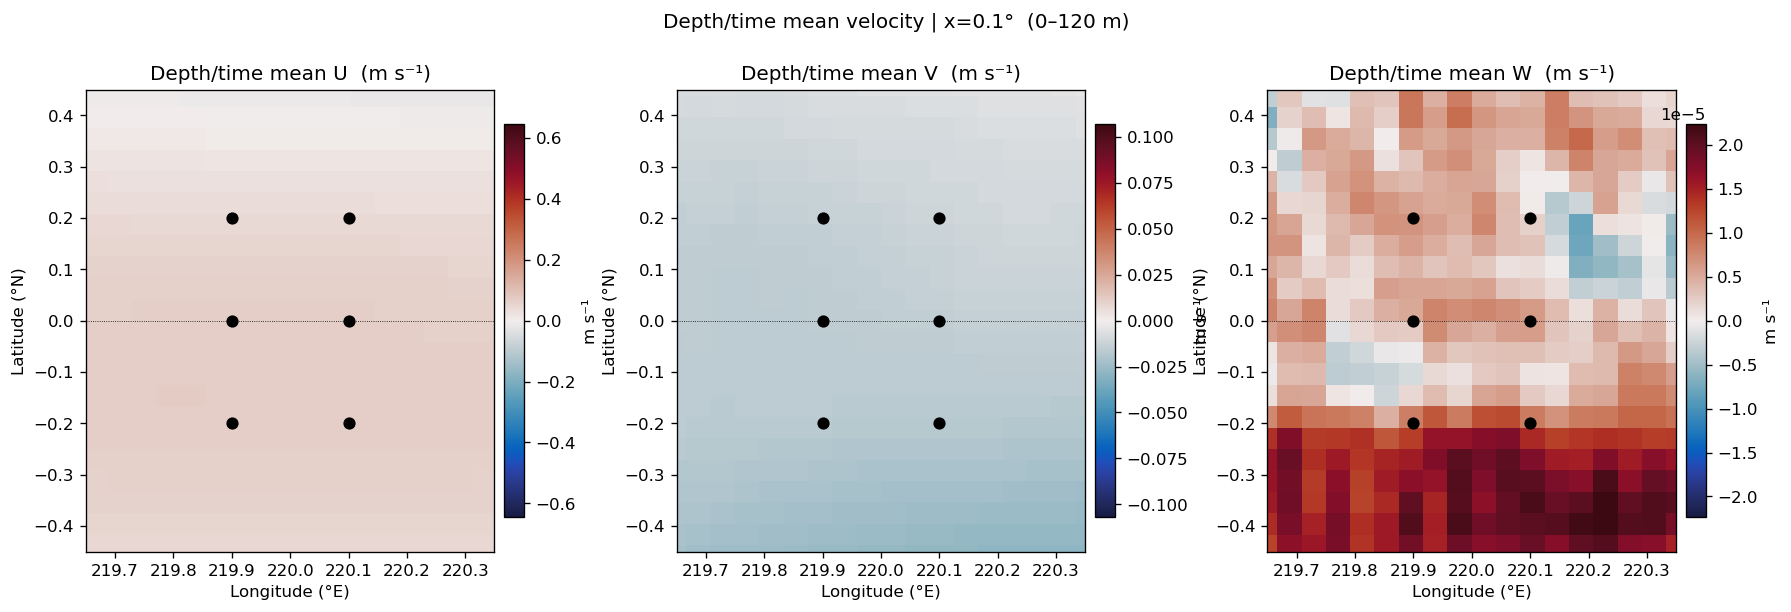

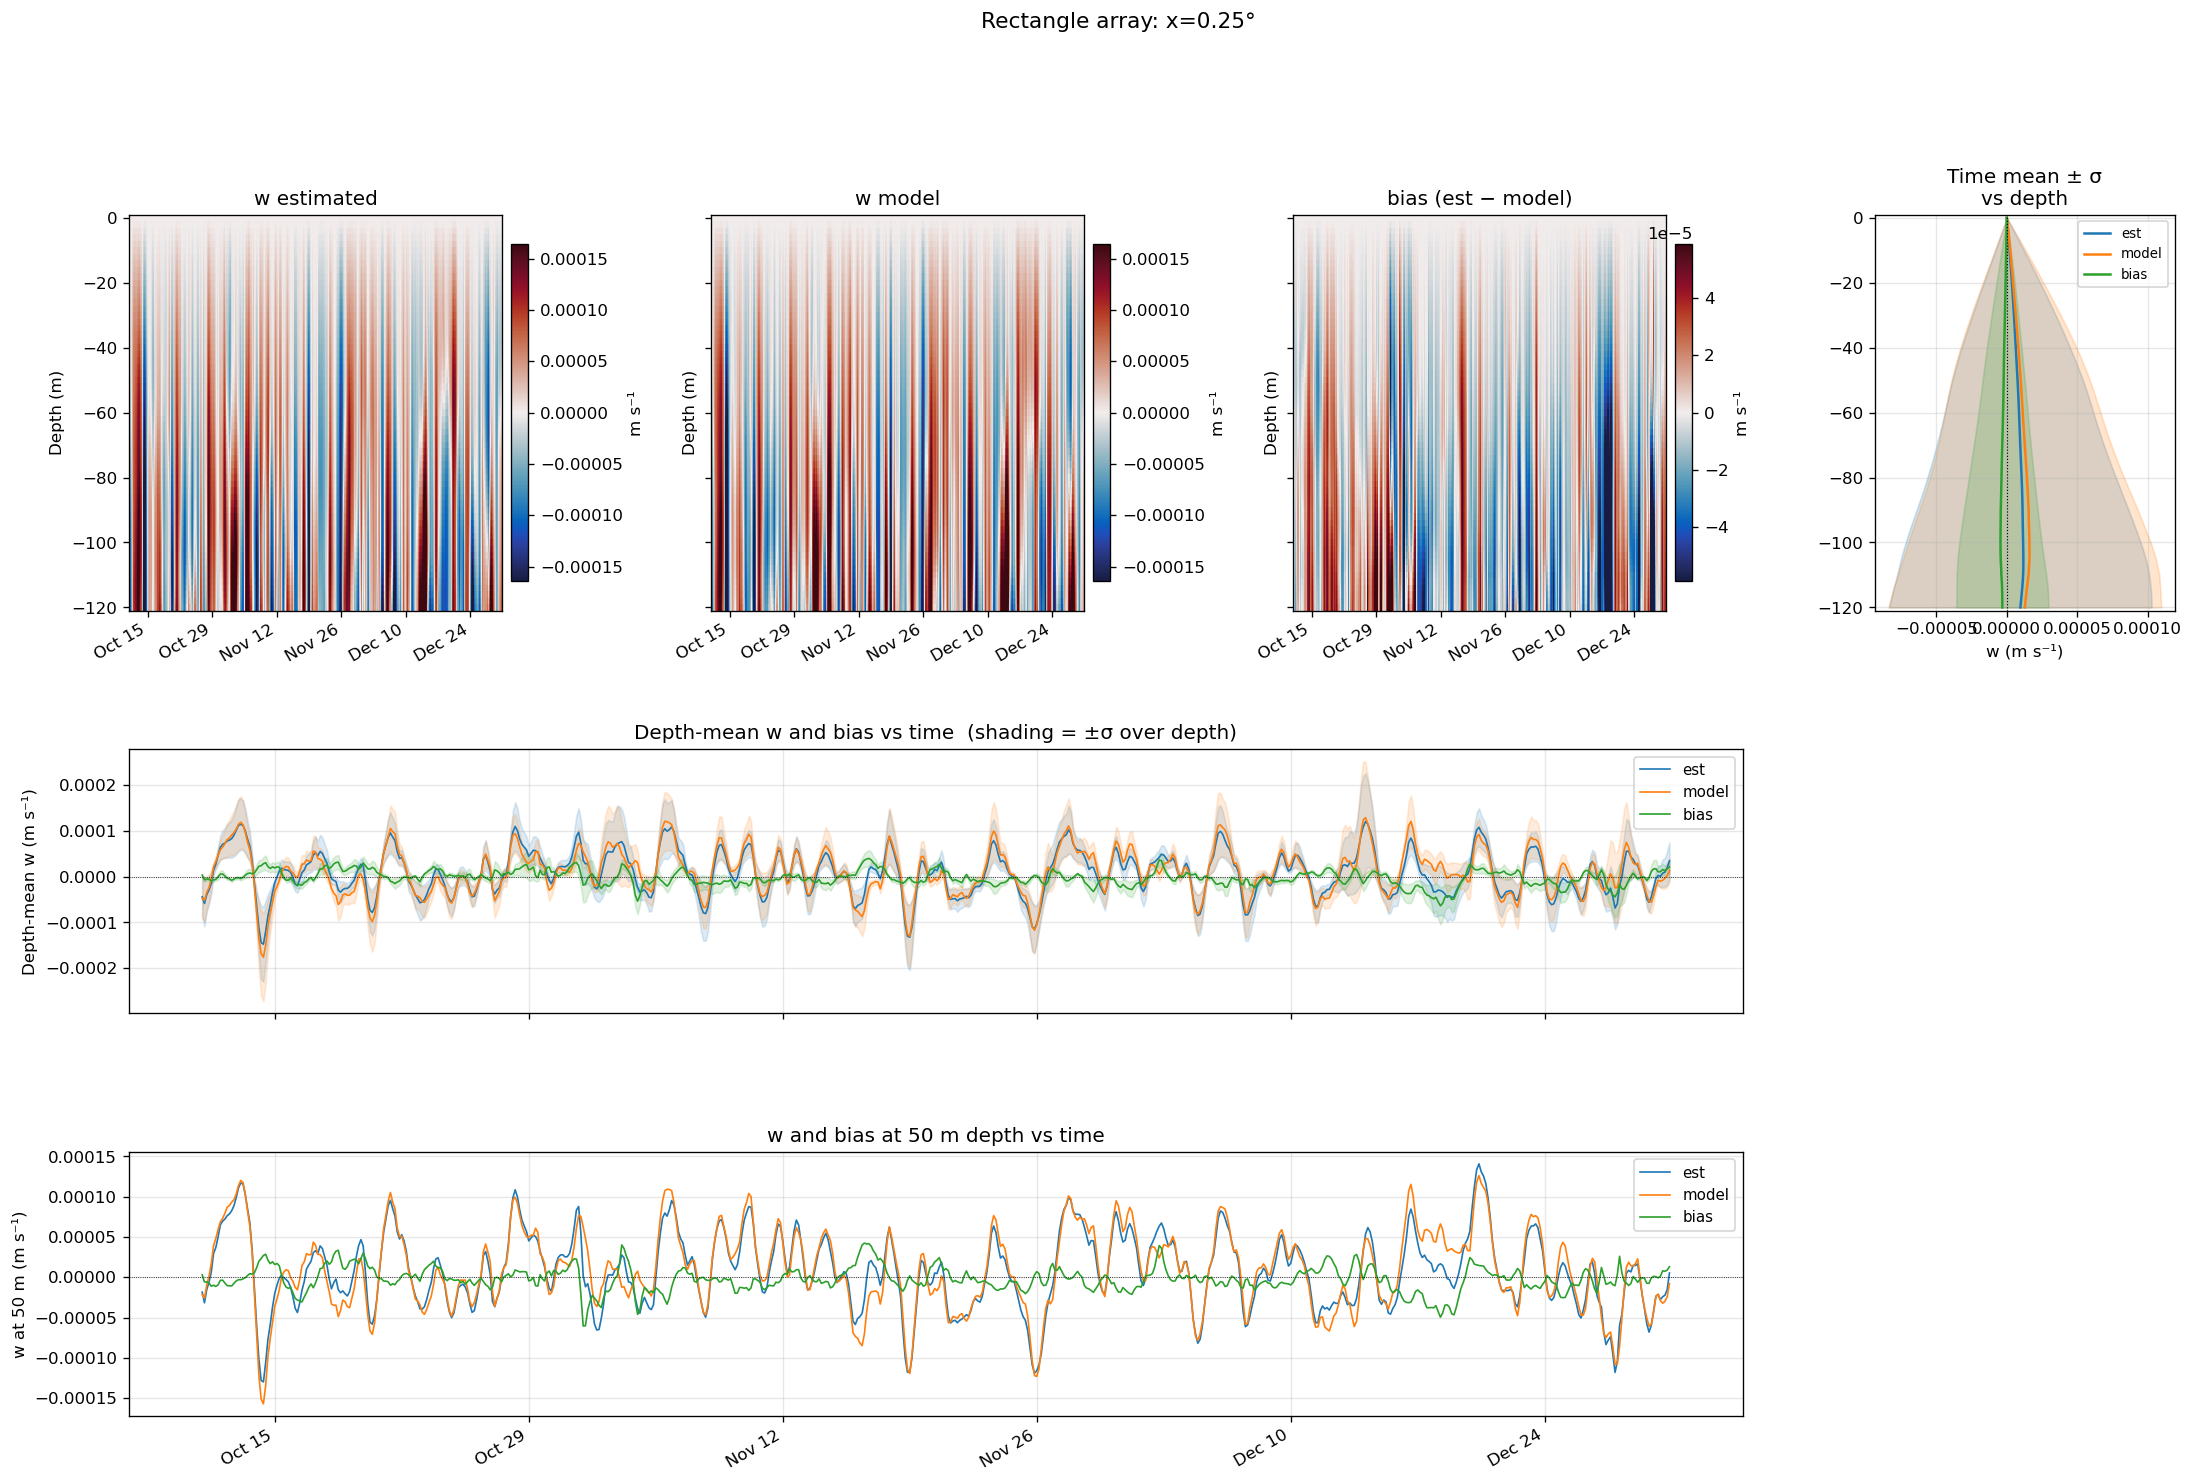

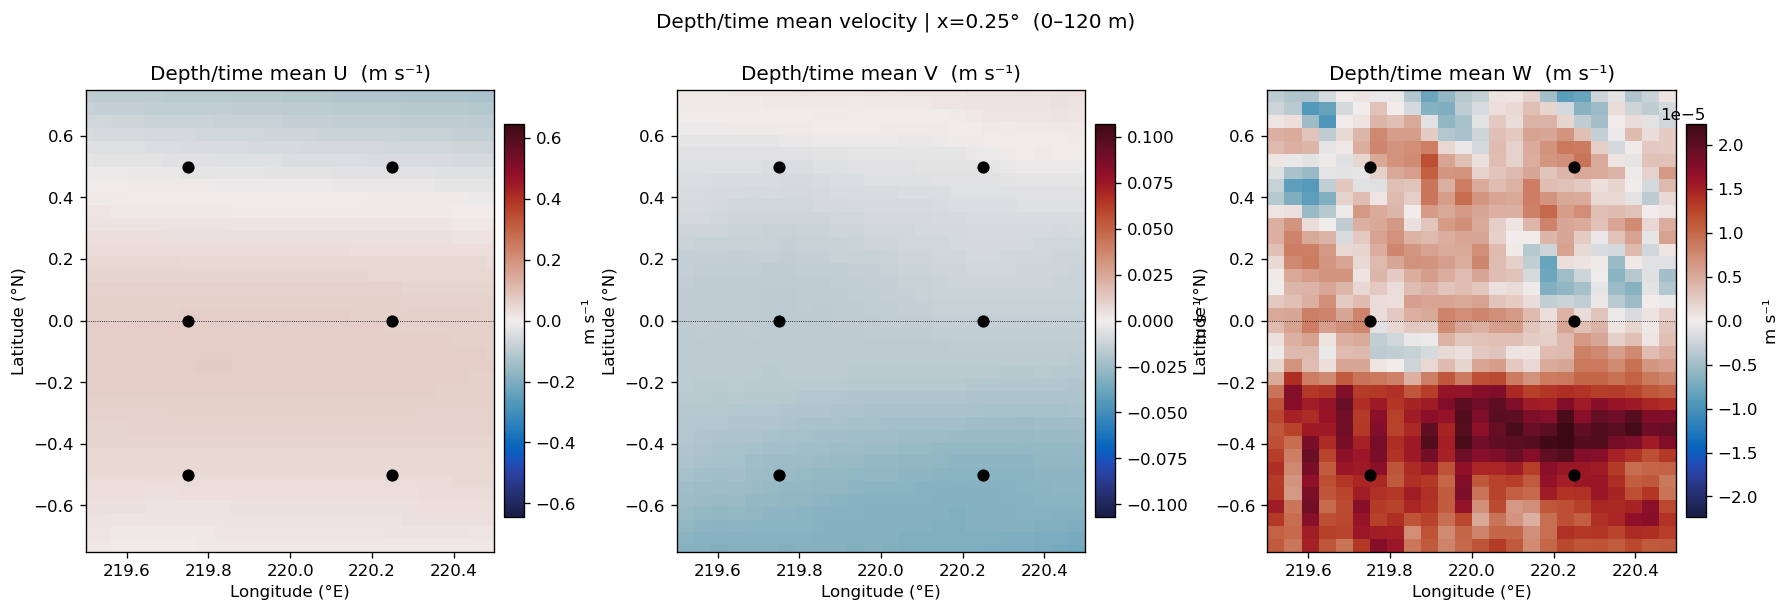

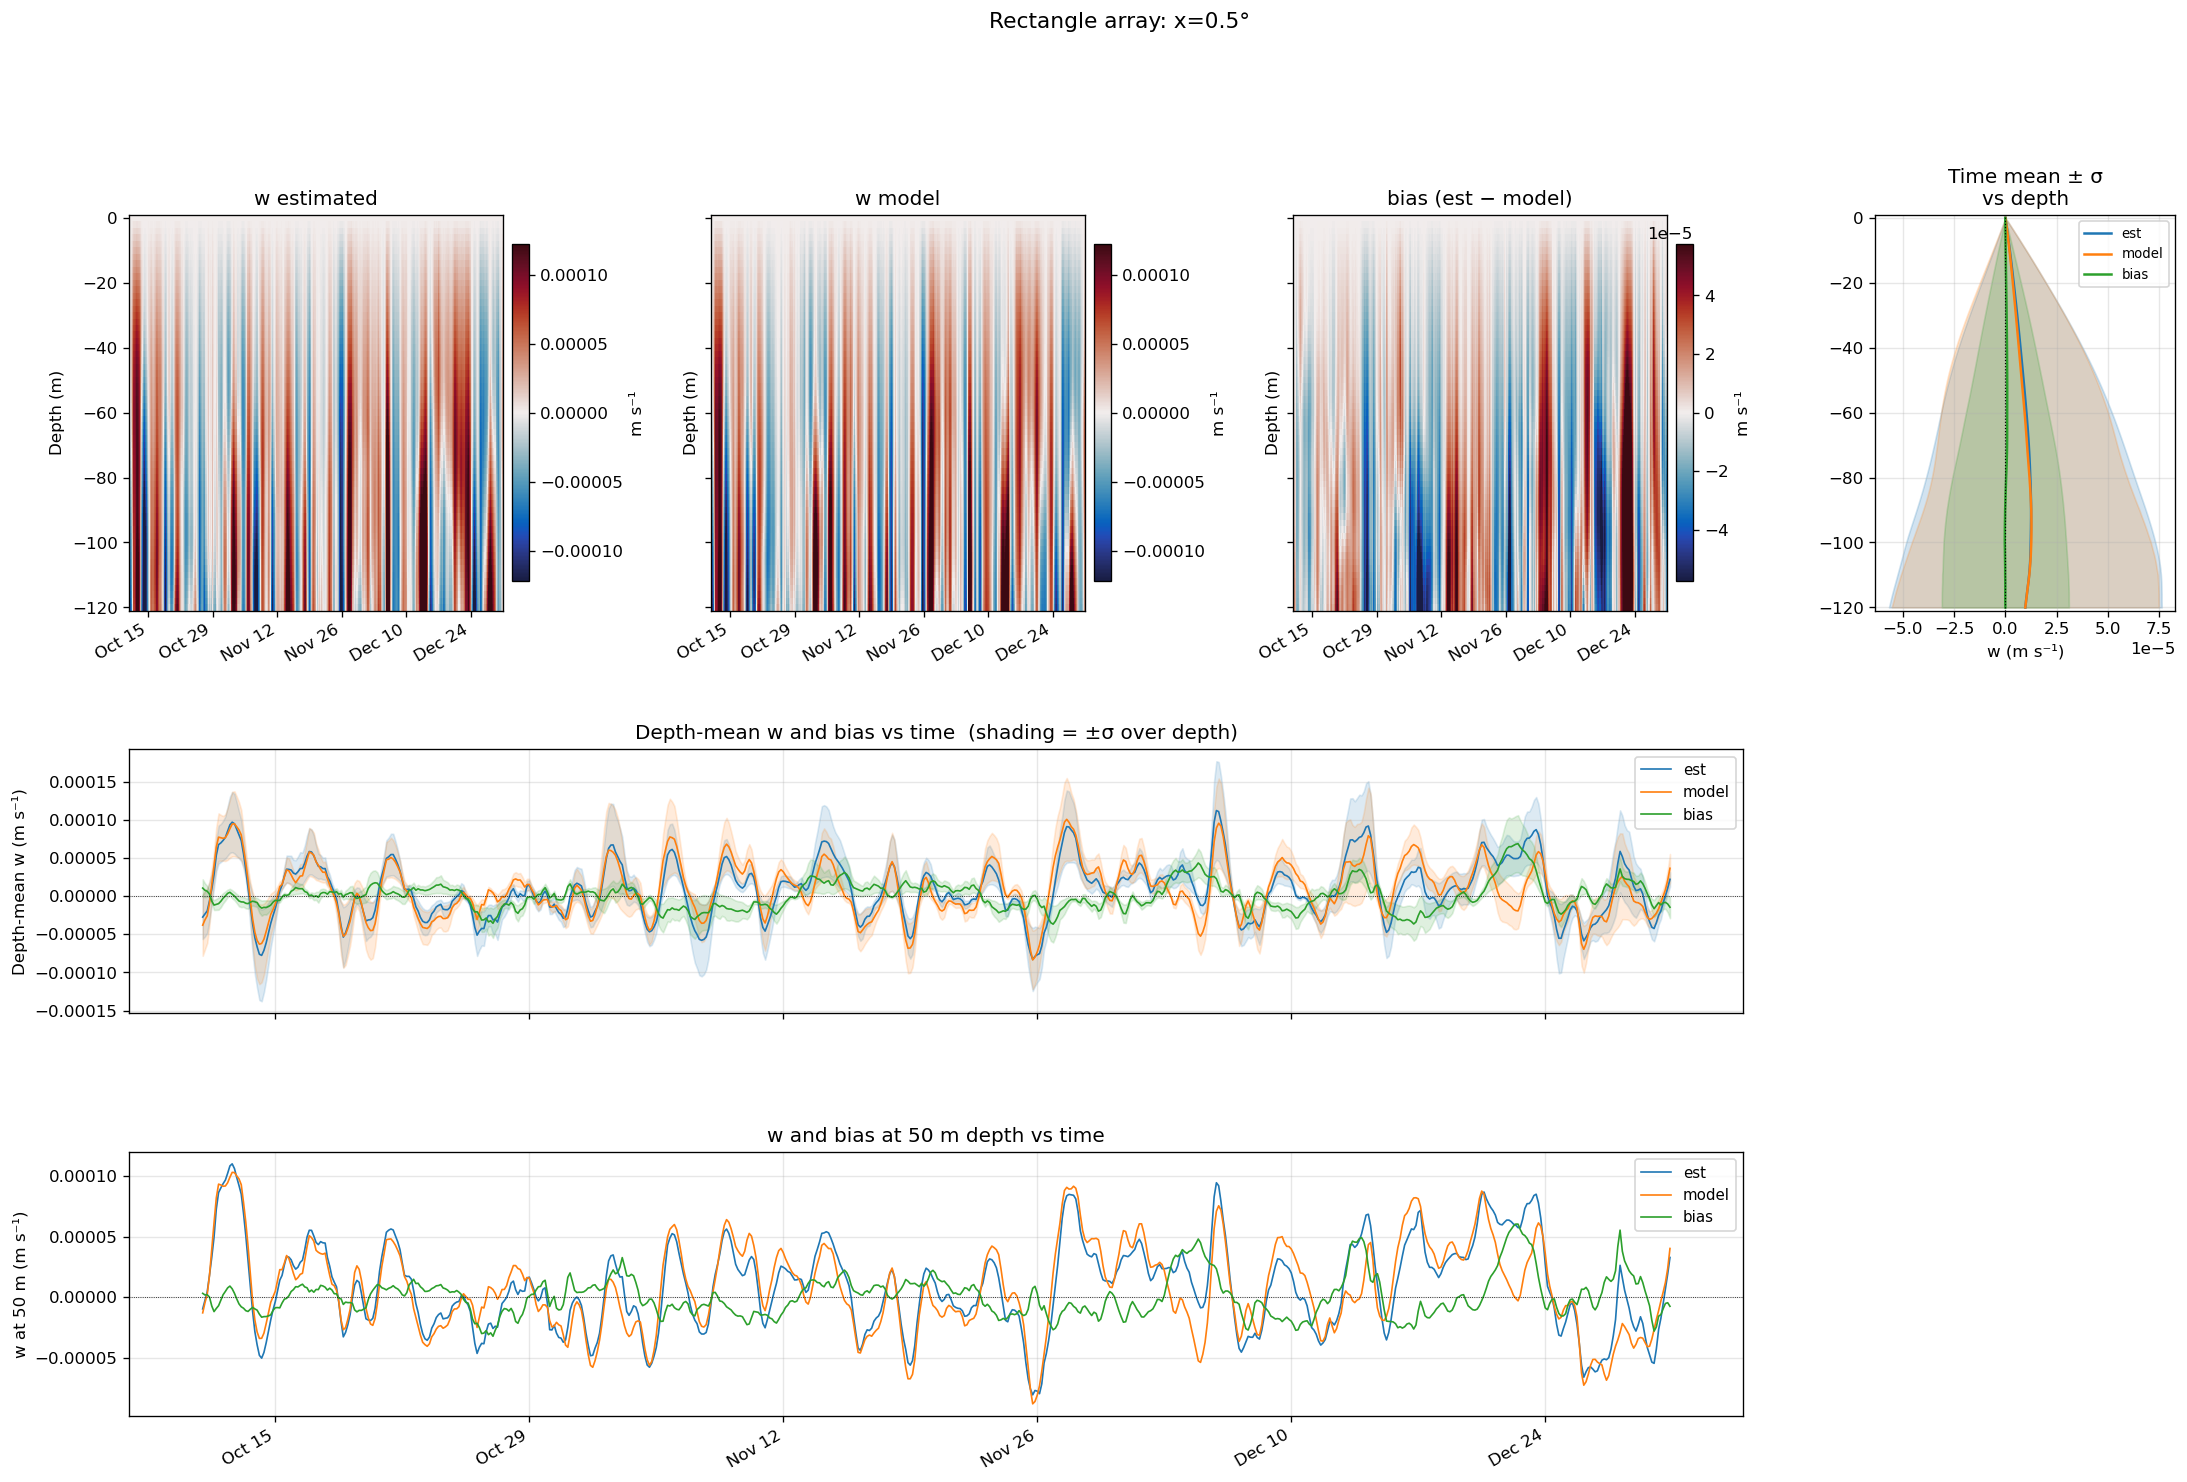

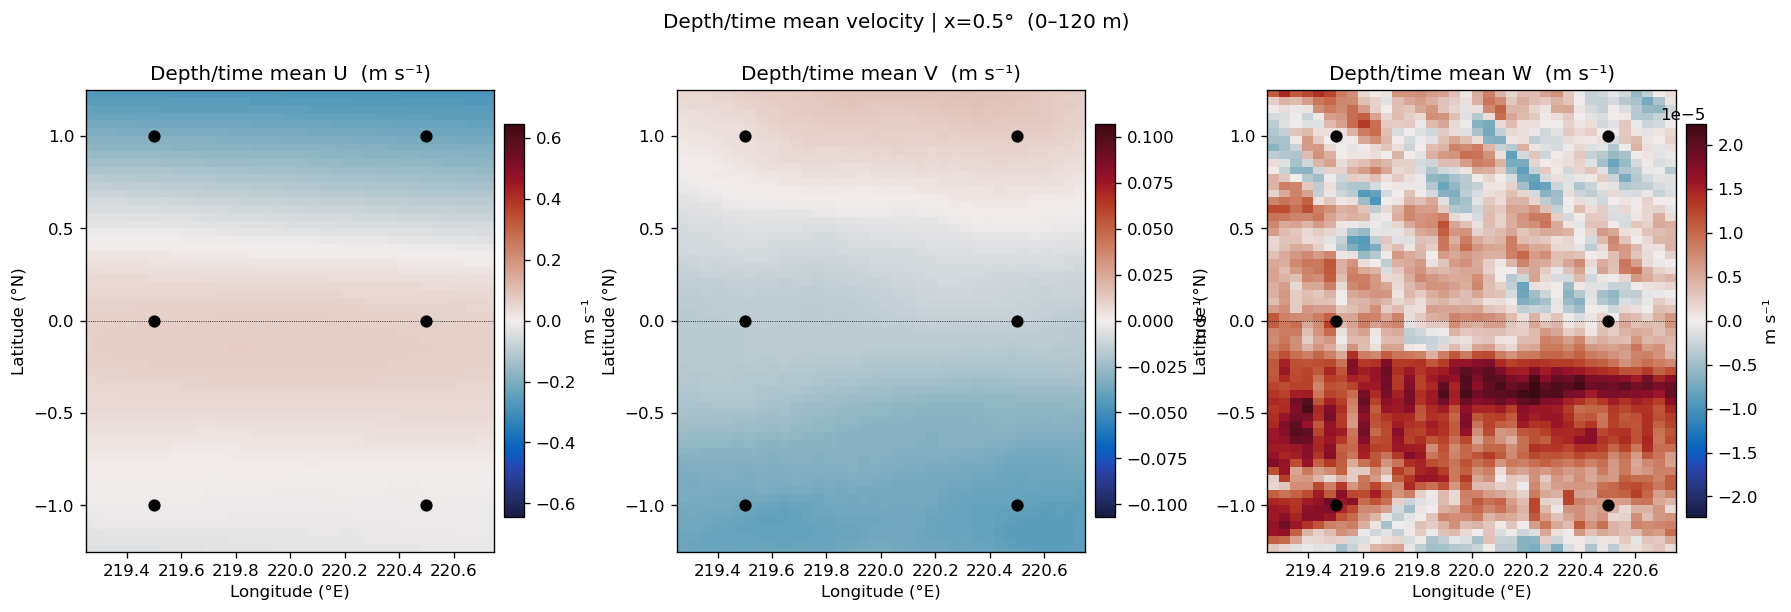

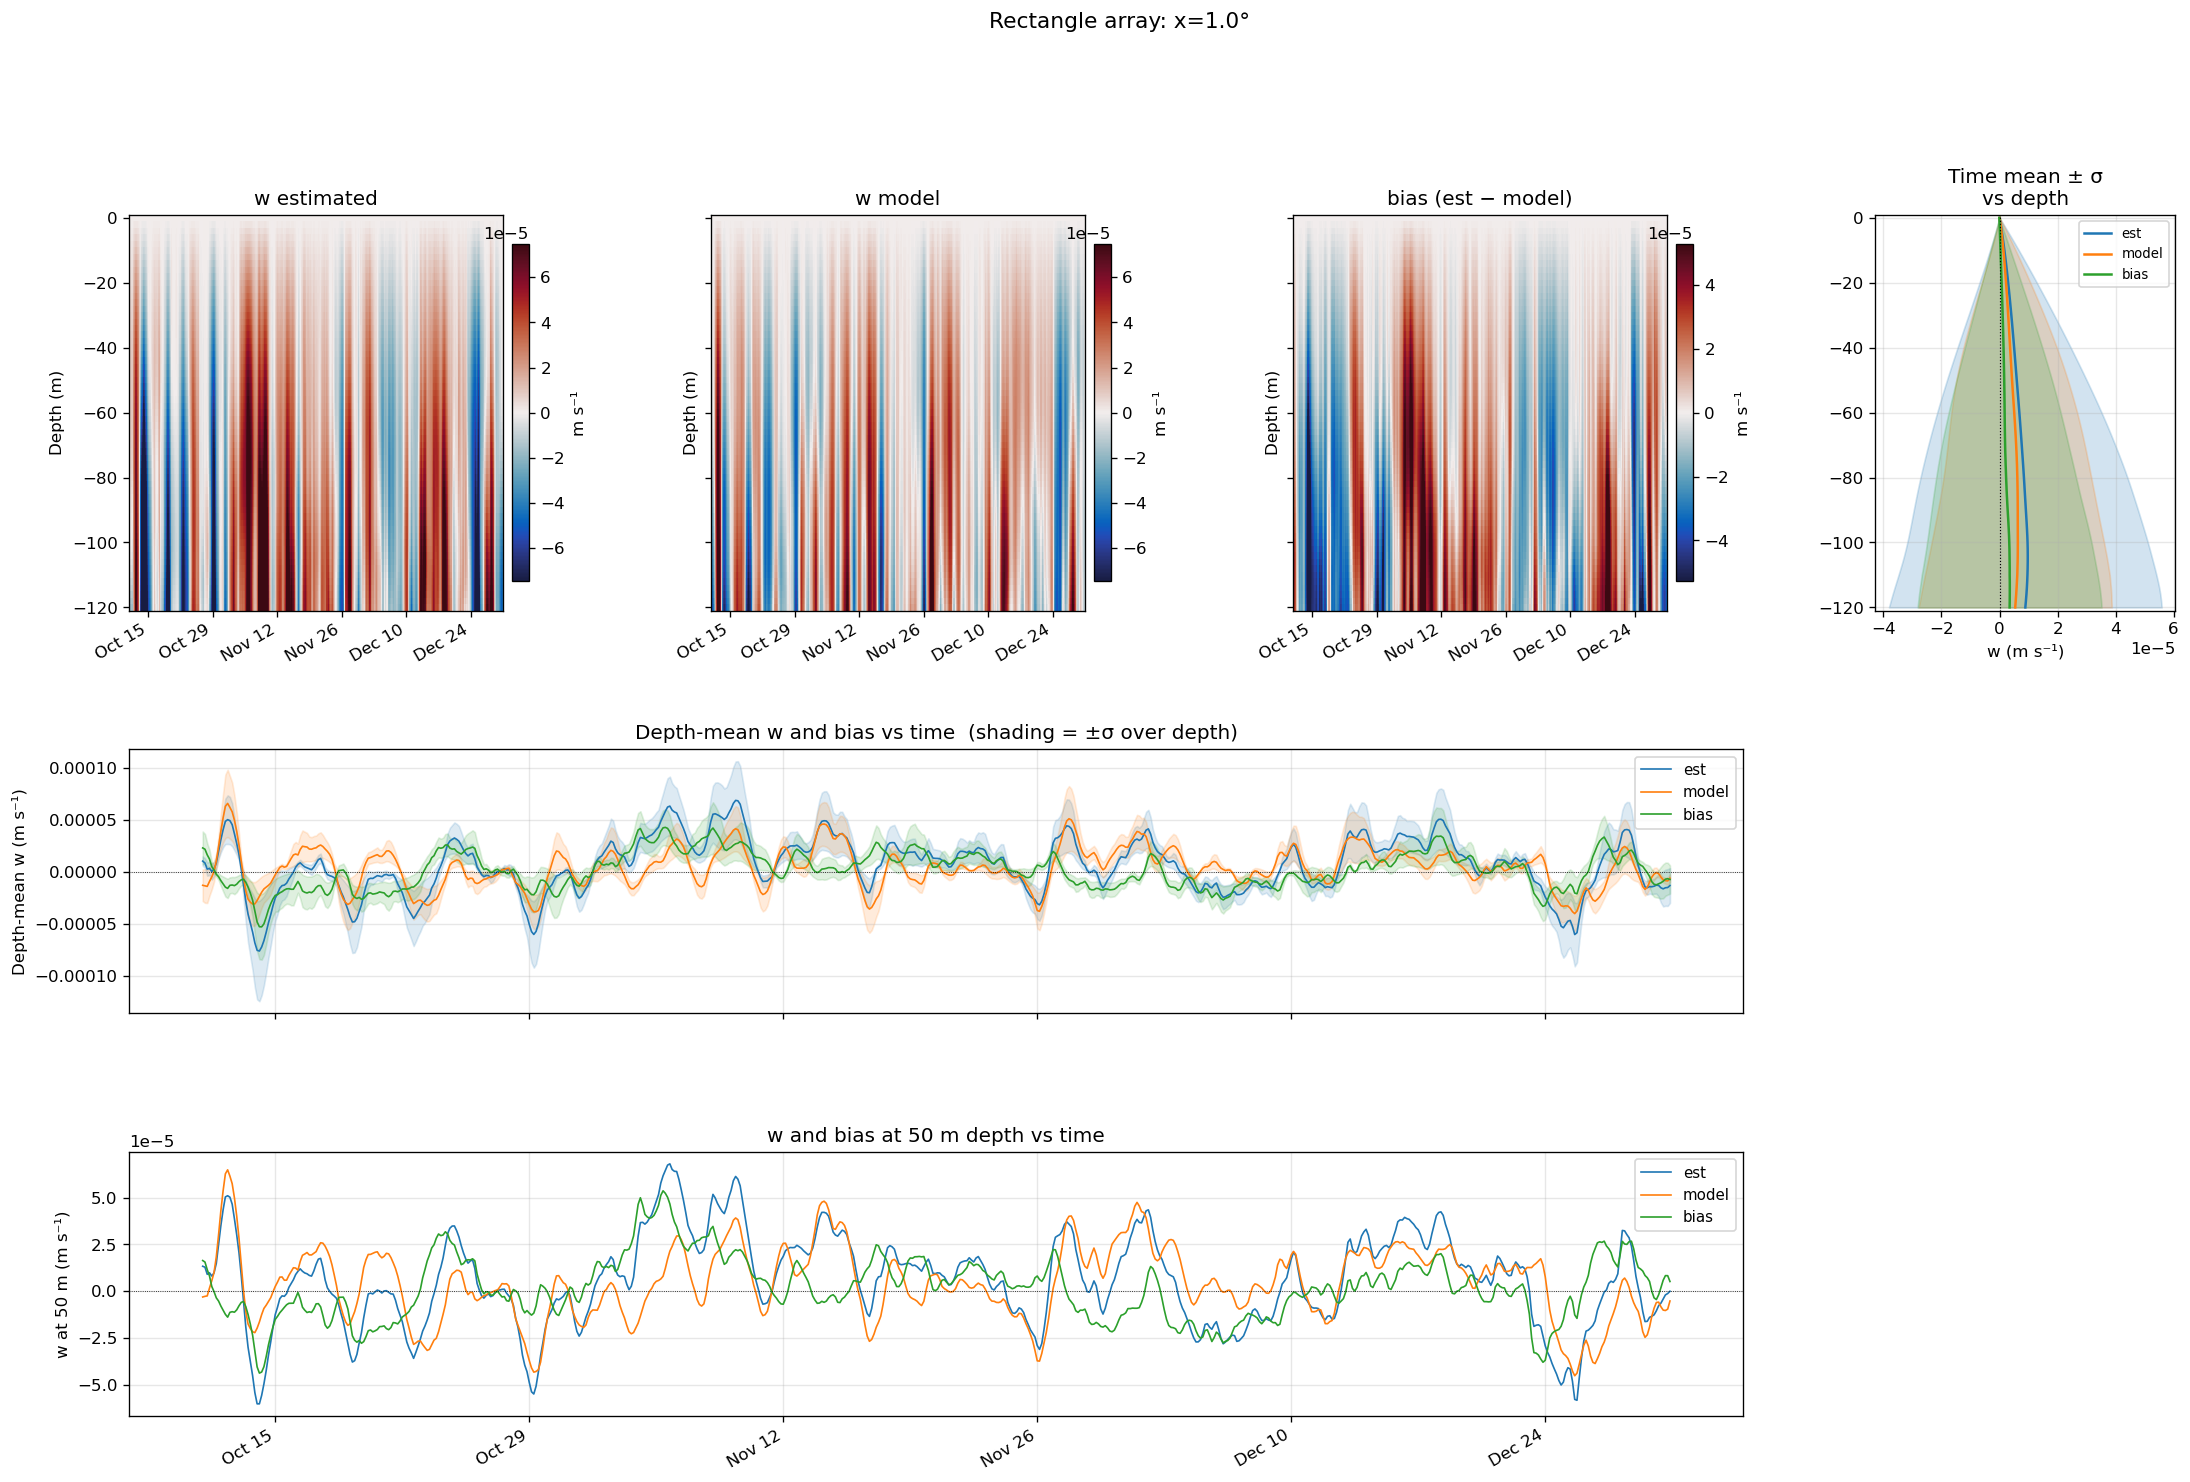

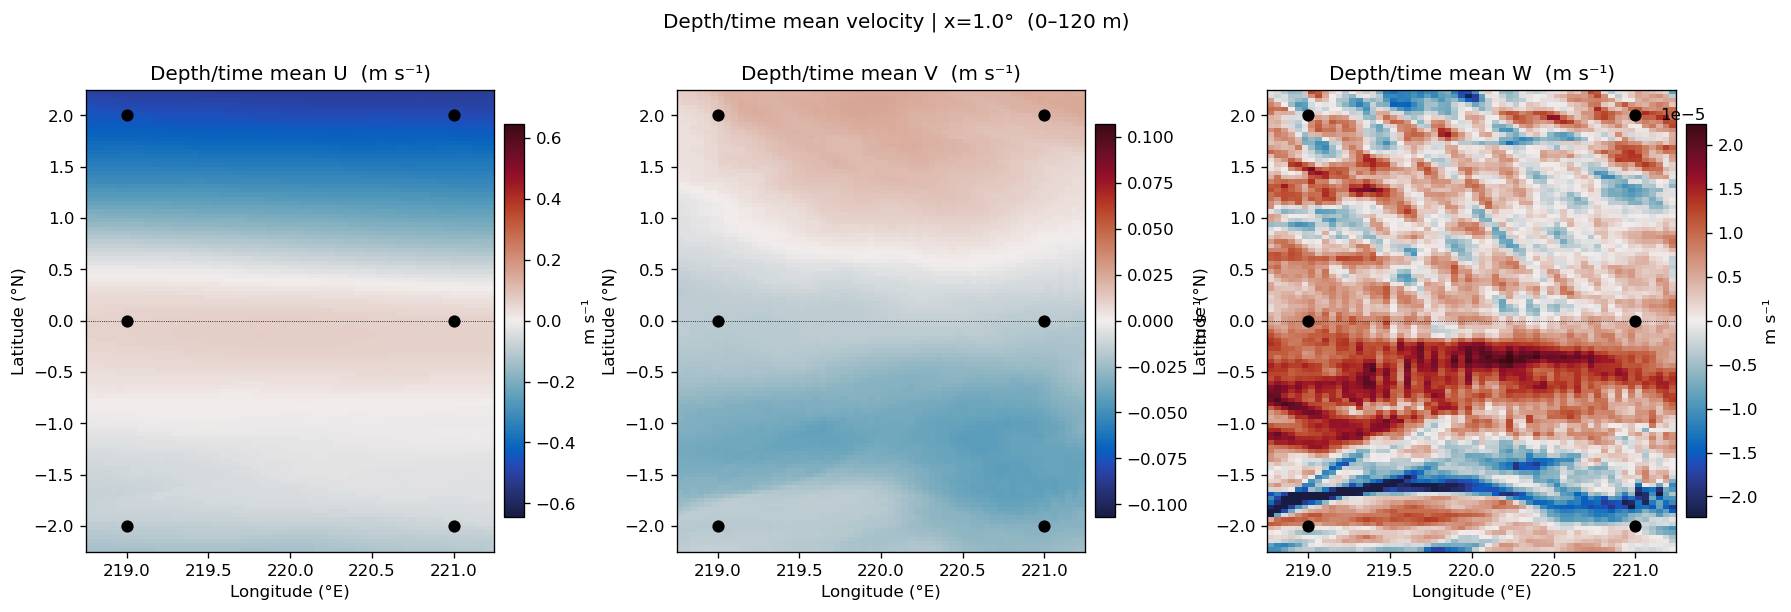

In [5]:
for x, r in results.items():
    outdir = f'{BASE_OUTDIR}/box-x{x}'
    os.makedirs(outdir, exist_ok=True)
    fig = plot_w_comparison(r['w_est'], r['w_model'], point_depth=-50)
    fig.suptitle(f'Rectangle array: x={x}°', fontsize=13, y=1.01)
    plt.savefig(f'{outdir}/w_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    fig2 = plot_velocity_map(ds, r['positions'], max_depth=MAX_DEPTH)
    fig2.suptitle(f'Depth/time mean velocity | x={x}°  (0–{MAX_DEPTH} m)',
                  fontsize=12, y=1.01)
    plt.savefig(f'{outdir}/velocity_map.png', dpi=150, bbox_inches='tight')
    plt.show()

## Summary comparison

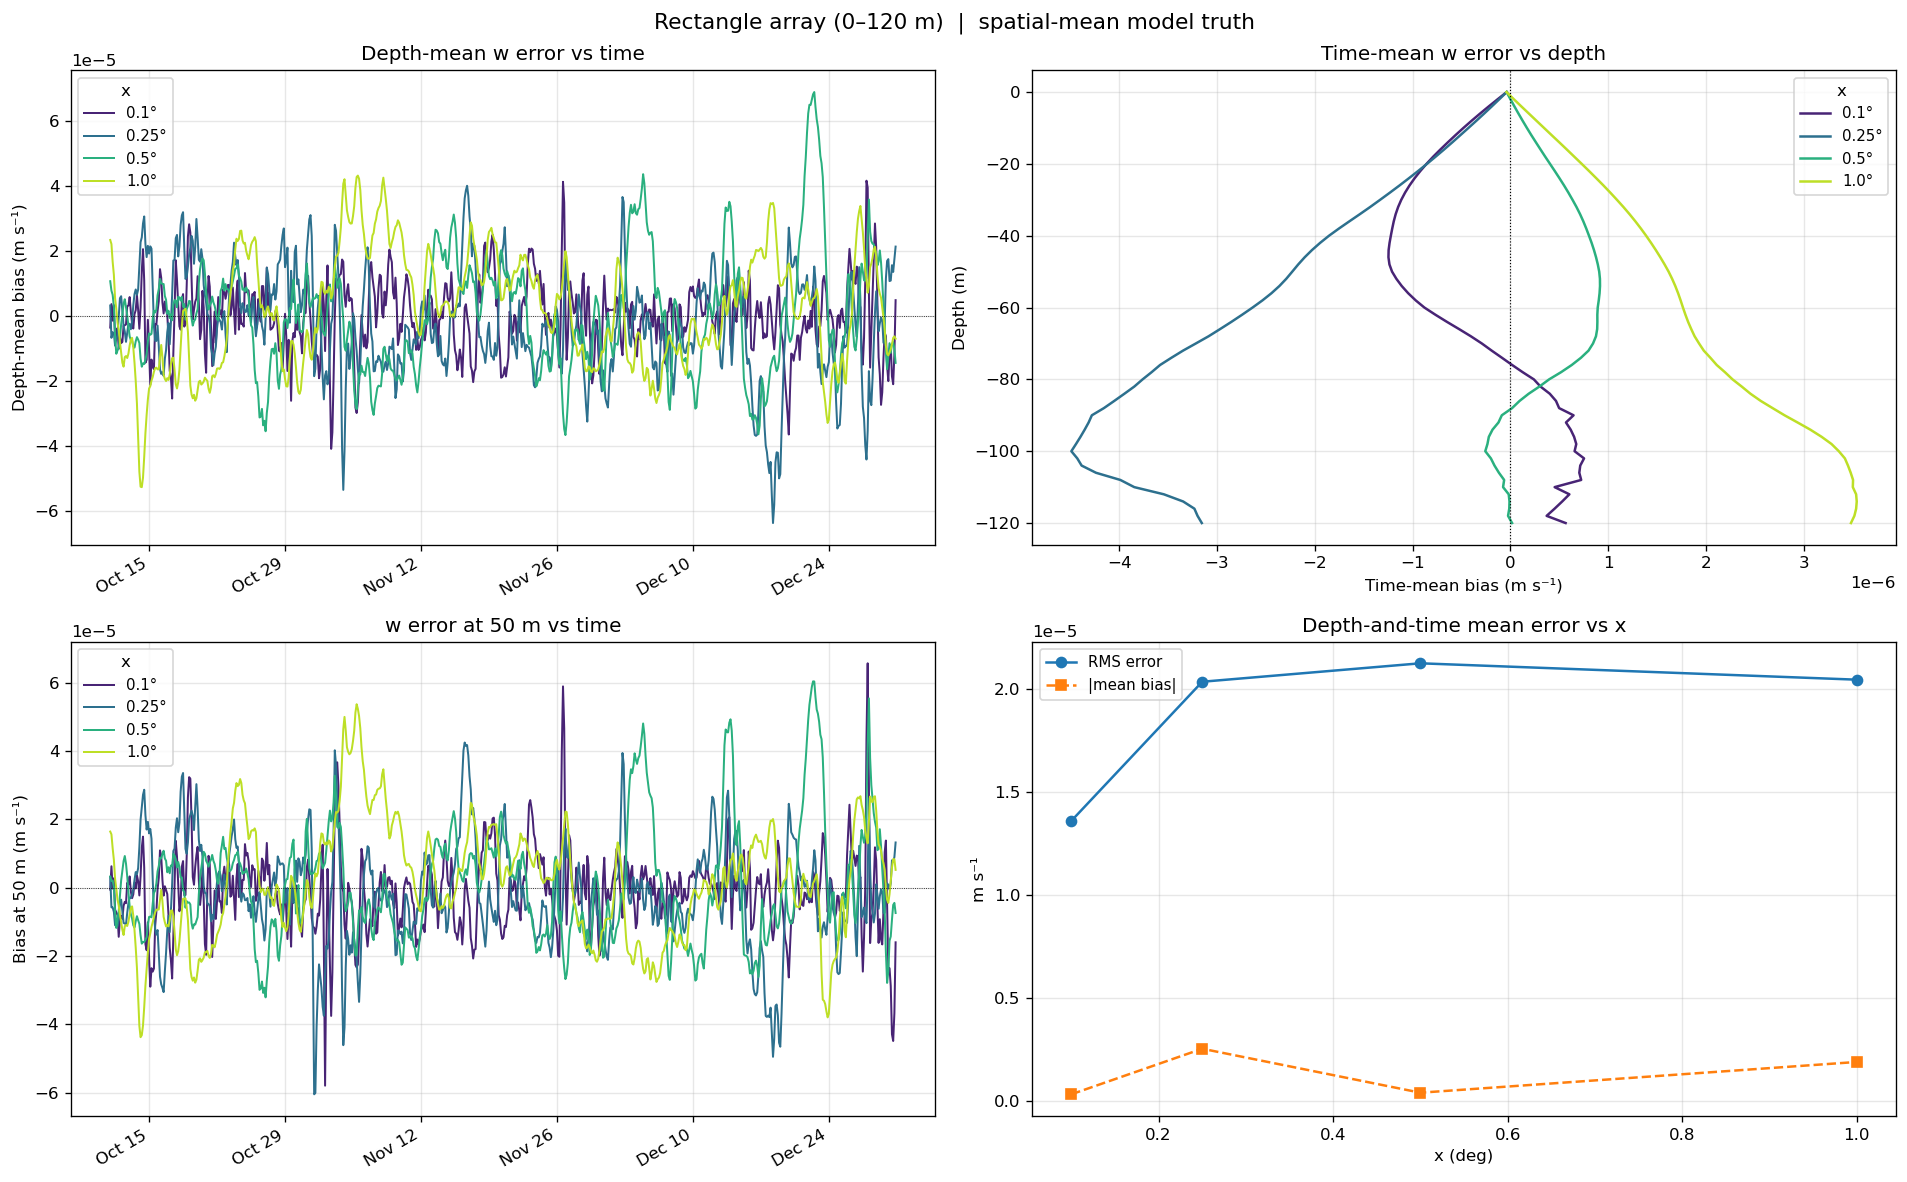

In [6]:
x_vals = sorted(results.keys())
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(x_vals)))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for (k, r), color in zip(sorted(results.items()), colors):
    T = r['bias'].time.values
    Z = r['bias'].depth.values
    label = f'{k}°'
    axes[0, 0].plot(T, r['bias'].mean('depth').values, color=color, lw=1.2, label=label)
    axes[0, 1].plot(r['bias'].mean('time').values, Z,  color=color, lw=1.5, label=label)
    axes[1, 0].plot(T, r['bias'].sel(depth=-50, method='nearest').values,
                    color=color, lw=1.2, label=label)

axes[0, 0].axhline(0, color='k', lw=0.5, ls=':')
axes[0, 0].set_ylabel('Depth-mean bias (m s⁻¹)')
axes[0, 0].set_title('Depth-mean w error vs time')
axes[0, 0].legend(title='x', fontsize=9); axes[0, 0].grid(alpha=0.3)
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[0, 0].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[0, 1].axvline(0, color='k', lw=0.7, ls=':')
axes[0, 1].set_xlabel('Time-mean bias (m s⁻¹)'); axes[0, 1].set_ylabel('Depth (m)')
axes[0, 1].set_title('Time-mean w error vs depth')
axes[0, 1].legend(title='x', fontsize=9); axes[0, 1].grid(alpha=0.3)

axes[1, 0].axhline(0, color='k', lw=0.5, ls=':')
axes[1, 0].set_ylabel('Bias at 50 m (m s⁻¹)')
axes[1, 0].set_title('w error at 50 m vs time')
axes[1, 0].legend(title='x', fontsize=9); axes[1, 0].grid(alpha=0.3)
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1, 0].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=30, ha='right')

rms_vals = [results[k]['rms']            for k in x_vals]
mb_vals  = [abs(results[k]['mean_bias']) for k in x_vals]
axes[1, 1].plot(x_vals, rms_vals, 'o-',  color='C0', lw=1.5, label='RMS error')
axes[1, 1].plot(x_vals, mb_vals,  's--', color='C1', lw=1.5, label='|mean bias|')
axes[1, 1].set_xlabel('x (deg)'); axes[1, 1].set_ylabel('m s⁻¹')
axes[1, 1].set_title('Depth-and-time mean error vs x')
axes[1, 1].legend(fontsize=9); axes[1, 1].grid(alpha=0.3)

fig.suptitle(f'{TITLE} (0–{MAX_DEPTH} m)  |  spatial-mean model truth', fontsize=13)
fig.tight_layout()
plt.savefig(f'{BASE_OUTDIR}/box_error_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary statistics

In [7]:
header = f"{'x (deg)':>10}  {'RMS (m/s)':>12}  {'Mean bias':>14}  {'w_est std':>12}  {'w_model std':>12}"
print(header); print('-' * len(header))
for k in sorted(results.keys()):
    r = results[k]
    print(f"{str(k)+chr(176):>10}  {r['rms']:>12.3e}  {r['mean_bias']:>+14.3e}  "
          f"{float(r['w_est'].std()):>12.3e}  {float(r['w_model'].std()):>12.3e}")

   x (deg)     RMS (m/s)       Mean bias     w_est std   w_model std
--------------------------------------------------------------------
      0.1°     1.359e-05      -3.077e-07     8.483e-05     8.593e-05
     0.25°     2.034e-05      -2.520e-06     5.846e-05     6.079e-05
      0.5°     2.124e-05      +3.850e-07     4.370e-05     4.226e-05
      1.0°     2.044e-05      +1.878e-06     3.003e-05     2.198e-05
